In [258]:
import sys
print(sys.executable)

c:\Users\elois\Github\mlops-ml-cloud\.venv\Scripts\python.exe


## ¿Qué es *data leakage*? 

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.


### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [271]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [272]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [273]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

Generando datos sintéticos de usuarios para targeting de promociones...
✅ Agregados 493 valores nulos en 'age_group' (5.0%)
✅ Agregados 298 valores nulos en 'location' (3.0%)
✅ Agregados 181 valores nulos en 'device_type' (2.0%)
✅ Agregados 106 valores nulos en 'subscription_type' (1.0%)
✅ Agregados 777 valores nulos en 'avg_order_value' (8.0%)
✅ Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
✅ Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
✅ Agregados 954 valores nulos en 'pages_per_session' (10.0%)
✅ Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
✅ Agregados 800 valores nulos en 'purchase_frequency' (8.0%)


,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

<Axes: >

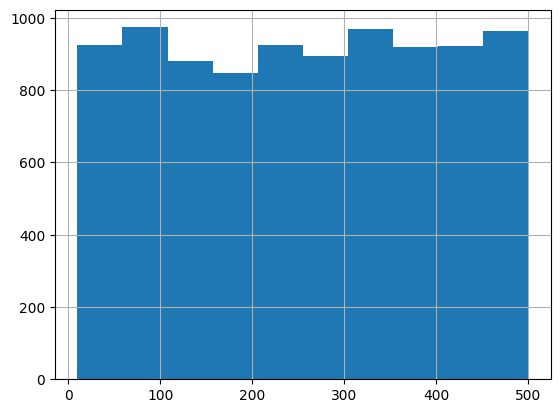

In [274]:
df.avg_order_value.hist()

In [275]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  str    
 1   age_group                9507 non-null   str    
 2   location                 9702 non-null   str    
 3   device_type              9819 non-null   str    
 4   subscription_type        9894 non-null   str    
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          9223 non-null   float64
 8   last_purchase_days       8526 non-null   float64
 9   sessions_last_30_days    10000 non-null  int64  
 10  time_on_site_minutes     9001 non-null   float64
 11  pages_per_session        9046 non-null   float64
 12  cart_abandonment_rate    8779 non-null   float64
 13  purchase_frequency       9200 non-null   float64
 14  dar_promocion            10000 non

In [276]:
df.describe()

,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
count,10000.000000,10000.000000,9223.000000,8526.000000,10000.000000,9001.000000,9046.000000,8779.000000,9200.000000,10000.000000
mean,179.228600,24.765700,256.321722,112.451677,15.063300,60.302922,10.453117,0.402694,7.294158,0.499500
std,105.853531,14.769313,142.446654,150.410931,8.958891,34.274278,5.485549,0.231219,9.086703,0.500025
min,0.000000,0.000000,10.020000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,87.000000,12.000000,130.060000,45.000000,7.000000,30.800000,5.700000,0.202500,2.000000,0.000000
50%,178.000000,25.000000,258.060000,93.000000,15.000000,59.300000,10.400000,0.404000,4.100000,0.000000
75%,271.000000,38.000000,380.150000,139.000000,23.000000,90.100000,15.200000,0.605000,8.140000,1.000000
max,365.000000,50.000000,499.950000,999.000000,30.000000,120.000000,20.000000,0.800000,50.000000,1.000000


**Observación**

1. De primeras podemos ver que al generar los datos sintéticos sí se lograron incluir valores faltantes. Esto se nota en la columna count, donde algunas variables tienen menos de 10,000 registros, lo que indica presencia de NaN.
2. La variable target `dar_promocion` está bastante bien balanceada, ya que su media es 0.4995, lo que indica que hay casi la misma cantidad de 0 y 1. Esto es bueno para el entrenamiento del modelo.
3. La variable `days_since_registration` tiene un comportamiento esperado, ya que va de 0 a 365 días, lo cual tiene sentido.
4. La variable `purchase_frequency` es curiosa porque aunque la mayoría de los valores están alrededor de 7–8 (según la media y el percentil 75), el valor máximo es 50, lo cual es bastante alto comparado con el resto. Esto podría indicar un comportamiento atípico o un posible outlier.
5. La variable `last_purchase_days` aunque el valor min indica 0 (0 días desde la ultima compra, muy reciente), si vemos que el max es 999, que es solo un indicador de usuarios que no han realizado compras. Realmente no es un outlier.






In [277]:
# Acá miro cuáles columnas tienen valores nulos y cuántos hay en cada una
df.isnull().sum().loc[lambda x: x > 0]

age_group                 493
location                  298
device_type               181
subscription_type         106
avg_order_value           777
last_purchase_days       1474
time_on_site_minutes      999
pages_per_session         954
cart_abandonment_rate    1221
purchase_frequency        800
dtype: int64

## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

In [279]:
days = df["days_since_registration"].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df["total_purchases_per_day"] = df["total_purchases"] / days

df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

# algunas variables nuevas

#  cual es el engagment de los usuarios? 
df["user_engagement"] = df["time_on_site_minutes"] * df["pages_per_session"]

# como es el engagment según la edad de los usuarios?

df["avg_engagement_by_age"] = df.groupby("age_group")["user_engagement"].transform("mean")

# que usuarios tienen mayor intención de abandono?

df["cart_abandonment_intent_score"] = df["user_engagement"] * df["cart_abandonment_rate"]




### **Variable `user_engagement`**

In [280]:
df[["time_on_site_minutes", "pages_per_session", "user_engagement"]].head(10)

,time_on_site_minutes,pages_per_session,user_engagement
0,71.3,NaN,NaN
1,34.1,17.5,596.75
2,43.7,7.5,327.75
3,106.4,7.9,840.56
4,55.0,16.8,924.00
5,30.1,9.8,294.98
6,38.5,6.1,234.85
7,30.3,11.7,354.51
8,6.6,3.1,20.46
9,113.1,13.9,1572.09


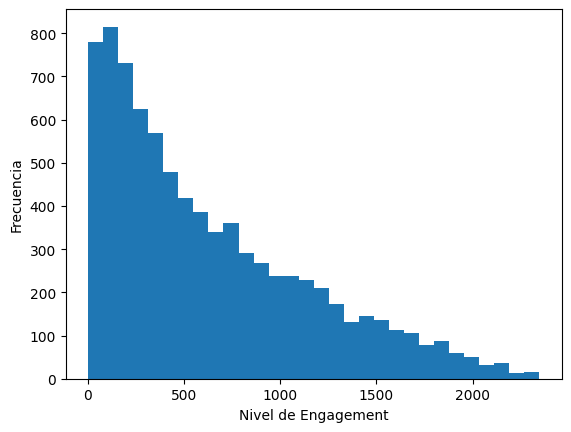

In [281]:
df["user_engagement"].hist(bins=30)

plt.xlabel("Nivel de Engagement")
plt.ylabel("Frecuencia")

plt.grid(False) 

plt.show()

### **Variable `avg_engagement_by_age`**

In [282]:
df[["age_group", "user_engagement", "avg_engagement_by_age"]].head()

,age_group,user_engagement,avg_engagement_by_age
0,18-25,NaN,635.305548
1,26-35,596.75,644.216616
2,36-45,327.75,614.054136
3,36-45,840.56,614.054136
4,18-25,924.00,635.305548


<Axes: xlabel='age_group'>

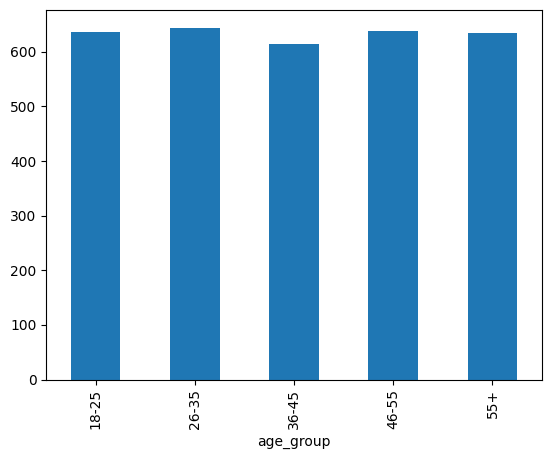

In [283]:
df.groupby("age_group")["avg_engagement_by_age"].mean().plot(kind="bar")

**Observación**

Realmente con esto, podemos observar que la variable edad no es determinante en el engagement que tienen los usuarios.

### **Variable `cart_abandonment_score`**

In [285]:
df[["user_engagement", "cart_abandonment_rate", "cart_abandonment_intent_score"]].head()

,user_engagement,cart_abandonment_rate,cart_abandonment_intent_score
0,NaN,0.075,NaN
1,596.75,0.607,362.22725
2,327.75,0.212,69.48300
3,840.56,0.154,129.44624
4,924.00,0.130,120.12000


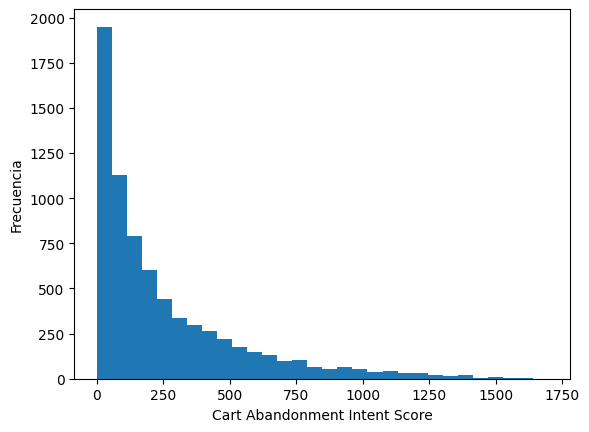

In [286]:
df["cart_abandonment_intent_score"].hist(bins=30)

plt.xlabel("Cart Abandonment Intent Score")
plt.ylabel("Frecuencia")

plt.grid(False) 

plt.show()

**Observación**

Con esta variable quería identificar a los usuarios que muestran interés y agregan productos al carrito, pero al final no completan la compra. La idea es poder incentivarlos un poco más, ya que al ofrecerles una promoción es más probable que terminen comprando. Y de acuerdo a la gráfica, los usuarios con score de 750+ son buenos candidatos.

### **Variable `days_between_first_and_last_purchase` y `last_purchase_days`**

In [287]:
df[["total_purchases_per_day", "days_between_first_and_last_purchase", "bucket_avg_order_value"]].head()

,total_purchases_per_day,days_between_first_and_last_purchase,bucket_avg_order_value
0,0.157895,-101.0,high
1,0.138211,132.0,medium
2,0.073944,187.0,low
3,0.102041,183.0,low
4,0.042424,233.0,high


In [288]:
# checar cuantos usuarios compraron sin haberse registrado
(df["last_purchase_days"] > df["days_since_registration"]).sum()

np.int64(2328)

**Observación**

Podemos observar que la variable `days_between_first_and_last_purchase`	tiene un valor negativo, pero esto se debe a que inicialmente en nuestra variable `last_purchase_days` teníamos un valor de 999 que representa "no compra", el usuario que se registró pero nunca compró.

También hay usuarios que tienen `last_purchase_days > days_since_registration`, lo que implicaría que compraron antes de registrarse (2117)

### **Nueva variable `never_purchased`**

In [289]:
print("Usuarios que nunca compraron:", (df["last_purchase_days"] == 999).sum())


Usuarios que nunca compraron: 211


In [290]:
# agrego una columna que indica si el usuario que se registró compró o no
df["never_purchased"] = (df["last_purchase_days"] == 999).astype(int)


In [291]:
print(df["never_purchased"].value_counts())

never_purchased
0    9789
1     211
Name: count, dtype: int64


In [292]:
# Y ya puedo cambiar el número de 999 en "las_purchase_days" por NaN para poder hacer el imputer
df["last_purchase_days"] = df["last_purchase_days"].replace(999, np.nan)

In [293]:
# Verificó que el valor máximo de "last_purchase_days" es menor a 999 para asegurarme que ya no hay valores de 999
df["last_purchase_days"].max()

np.float64(180.0)

In [294]:
# Vuelvo a calcular la columna de "days_between_first_and_last_purchase"
df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["days_between_first_and_last_purchase"] = df["days_between_first_and_last_purchase"].clip(lower=0)  # Evitar valores negativos, dejar 0 si el valor es menor a 0

print("Mínimo:", df["days_between_first_and_last_purchase"].min())

Mínimo: 0.0


**Observación**

Se creó una columna nueva `never_purchased` para poder categorizar si el usuario se registró pero nunca compró, e hice `.clip(lower=0)` para tratar la inconsistencia de `last_purchase_days > days_since_registration`.

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.expand_frame_repr", False)

df.head()

,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion,total_purchases_per_day,days_between_first_and_last_purchase,bucket_avg_order_value,never_purchased,avg_by_location,engagement_score,engagement,user_engagement,avg_engament_by_age,avg_engagment_by_age,avg_engagement_by_age,cart_abandonment_intent_score
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1,0.157895,-101.0,high,0,256.096557,NaN,NaN,NaN,635.305548,635.305548,635.305548,NaN
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0,0.138211,132.0,medium,0,255.567117,596.75,596.75,596.75,644.216616,644.216616,644.216616,362.22725
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1,0.073944,187.0,low,0,255.567117,327.75,327.75,327.75,614.054136,614.054136,614.054136,69.48300
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0,0.102041,183.0,low,0,258.591654,840.56,840.56,840.56,614.054136,614.054136,614.054136,129.44624
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1,0.042424,233.0,high,0,255.567117,924.00,924.00,924.00,635.305548,635.305548,635.305548,120.12000


## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [295]:
from sklearn.model_selection import train_test_split

# Separación de variables predictoras (X) y variable objetivo (y, "dar_promocion")

x_features = df.drop(columns=["dar_promocion", "user_id", "pages_per_session", "time_on_site_minutes","cart_abandonment_rate"]) # Quitamos igual user_id porque cuando hago passthrough en el pipeline, me arroja error. 
y_target= df["dar_promocion"]

# Hacemos el split entre X y Y (70/30)
X_train, X_test, y_train, y_test =train_test_split(
    x_features, 
    y_target, test_size=0.3, 
    random_state=42,
    stratify=y_target
    )    

# Checamos el shape de las variables de entreno y prueba X, Y
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(7000, 17)
(7000,)
(3000, 17)
(3000,)


## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown="ignore"`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

In [296]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [297]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   user_id                               10000 non-null  str     
 1   age_group                             9507 non-null   str     
 2   location                              9702 non-null   str     
 3   device_type                           9819 non-null   str     
 4   subscription_type                     9894 non-null   str     
 5   days_since_registration               10000 non-null  int64   
 6   total_purchases                       10000 non-null  int64   
 7   avg_order_value                       9223 non-null   float64 
 8   last_purchase_days                    8315 non-null   float64 
 9   sessions_last_30_days                 10000 non-null  int64   
 10  time_on_site_minutes                  9001 non-null   float64 
 11  pages_per_sess

In [298]:
df.columns

Index(['user_id', 'age_group', 'location', 'device_type', 'subscription_type',
       'days_since_registration', 'total_purchases', 'avg_order_value',
       'last_purchase_days', 'sessions_last_30_days', 'time_on_site_minutes',
       'pages_per_session', 'cart_abandonment_rate', 'purchase_frequency',
       'dar_promocion', 'total_purchases_per_day',
       'days_between_first_and_last_purchase', 'bucket_avg_order_value',
       'user_engagement', 'avg_engagement_by_age',
       'cart_abandonment_intent_score', 'never_purchased'],
      dtype='str')

In [299]:
# Clasificamos cada columna como numérica o categórica
# No agrego columnas como ""time_on_site_minutes" o "pages_per_session" porque ya tengo la variable de "user_engagement" y la del "cart_abandonment_rate"
numeric_features = [
    "days_since_registration",
    "total_purchases",
    "avg_order_value",
    "sessions_last_30_days",
    "purchase_frequency",
    "total_purchases_per_day",
    "days_between_first_and_last_purchase",
    "last_purchase_days",
    "user_engagement",
    "avg_engagement_by_age",
    "cart_abandonment_intent_score",
]
categorical_features = ["age_group", "location", "device_type", "subscription_type", "bucket_avg_order_value"]


### **Pipelines y transformaciones**

In [301]:
# Transformaciones numéricas, MinMax Scaler para escalar las variables numéricas
# Imputar los valores faltantes con KNN Imputer, que reemplaza los valores faltantes con la media de los k vecinos más cercanos

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from category_encoders import BinaryEncoder


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")), # imputar para reemplazar valores faltantes
        ("scaler", MinMaxScaler()), # Agrego MinMaxScaler para escalar entre 0 y 1
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        ("encoder", BinaryEncoder()), # Reduces dimensionality, more memory-efficient than one-hot encoding.
    ]
)
# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="passthrough",  # Esto para la columna nueva que creé de "never_purchased"
)

# Create the full pipeline

pipeline_trees = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

# Creación del GridSearchCV
param_grid = {
    "classifier__n_estimators":      [100, 200],   # It defines the number of trees in the forest
    "classifier__max_depth":         [None, 10, 20], # Controls the maximum depth of each tree. A shallow tree may underfit while a deep tree may overfit.
    "classifier__min_samples_split": [2, 5, 10], # Specifies the minimum number of samples required to split an internal node
    "classifier__min_samples_leaf":  [1, 2,4], # Specifies the minimum number of samples required to be at a leaf node. A smaller leaf may capture more specific patterns but can lead to overfitting, while a larger leaf may generalize better but miss finer details.
    "classifier__max_features":      ["sqrt", "log2"], #  Limits the number of features to consider when splitting a node
    # sqrt: Selects the square root of the total features. This is a common setting to reduce overfitting and speed up the model.
    # log2: This option selects the base-2 logarithm of the total number of features. It provide more randomness and reduce overfitting more than the square root option.
}
grid_search = GridSearchCV(
    estimator= pipeline_trees,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit the pipeline
grid_search.fit(X_train, y_train)


print(f'"Best Parameters:", {grid_search.best_params_}"')
print(f'"Best F1 (CV): {grid_search.best_score_}"')

best_model = grid_search.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
"Best Parameters:", {'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}"
"Best F1 (CV): 0.511"


**Observación**

GridSearchCV evaluó 540 combinaciones y encontró como mejores hiperparámetros `n_estimators=100`, `max_features=log2` y `min_samples_split=5`, `min_samples_leaf=1` on un F1 de 0.511 en validación cruzada.


### (Opcional) Ver cuántas features quedan después del preprocesamiento

`BinaryEncoder` vs `OneHotEncoder (27 columnas)`. Esto es normal. Aquí solo inspeccionamos:

- cuántas columnas finales existen
- algunos nombres generados

Esto es útil para debugging e interpretabilidad (aun si luego no interpretas coeficientes).

In [302]:
try:
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    print("Nº de features después del preprocesamiento:", len(feature_names))
    pd.Series(feature_names).head(20)
except Exception as e:
    print("No se pudieron obtener los nombres de features:", e)

Nº de features después del preprocesamiento: 27


In [304]:
feature_names

array(['num__days_since_registration', 'num__total_purchases',
       'num__avg_order_value', 'num__sessions_last_30_days',
       'num__purchase_frequency', 'num__total_purchases_per_day',
       'num__days_between_first_and_last_purchase',
       'num__last_purchase_days', 'num__user_engagement',
       'num__avg_engagement_by_age', 'num__cart_abandonment_intent_score',
       'cat__0_0', 'cat__0_1', 'cat__0_2', 'cat__1_0', 'cat__1_1',
       'cat__1_2', 'cat__2_0', 'cat__2_1', 'cat__2_2', 'cat__3_0',
       'cat__3_1', 'cat__3_2', 'cat__4_0', 'cat__4_1', 'cat__4_2',
       'remainder__never_purchased'], dtype=object)

**Observación**

Obtuve 27 columnas, igual al ejemplo que compartiste, profe. Entiendo que BinaryEncoder genera menos columnas que OneHotEncoder por el tema de la dimensionalidad, pero en este caso agregué las features adicionales que se crearon más arriba, más las nuevas columna, entre esas `never_purchased`, y sigue siendo menos que las que OneHotEncoder hubiese generado.

In [305]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [306]:
y_pred_proba

array([0.50033333, 0.53577381, 0.39433333, ..., 0.48629762, 0.40927778,
       0.40291667], shape=(3000,))

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

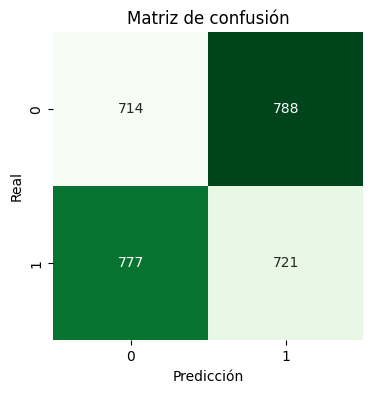

In [307]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

**Observación**

El modelo de RandomForestClassifier usando la estrategia de SimpleImputer con mean tiende a predecir la clase 1; los falsos positivos (788) superan los verdaderos negativos (714), y en este caso le estaríamos dando promociones a usuarios que no las necesitan. Con esto puedo inferir que el modelo esta sesgado hacía la clase 1.

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [308]:
from sklearn.metrics import classification_report

for thr in [0.3, 0.5, 0.7]:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    print(f"\n--- Threshold = {thr} ---")
    print(classification_report(y_test, y_pred_thr))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.22      0.00      0.00      1502
           1       0.50      1.00      0.66      1498

    accuracy                           0.50      3000
   macro avg       0.36      0.50      0.33      3000
weighted avg       0.36      0.50      0.33      3000


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.48      0.48      0.48      1502
           1       0.48      0.48      0.48      1498

    accuracy                           0.48      3000
   macro avg       0.48      0.48      0.48      3000
weighted avg       0.48      0.48      0.48      3000


--- Threshold = 0.7 ---
              precision    recall  f1-score   support

           0       0.50      0.99      0.66      1502
           1       0.23      0.00      0.00      1498

    accuracy                           0.50      3000
   macro avg       0.37      0.50      0.33      3000

### **AUC ROC**

AUC-ROC curve is a graph used to check how well a binary classification model works. It helps us to understand how well the model separates the positive cases like people with a disease from the negative cases like people without the disease at different threshold level. It shows how good the model is at telling the difference between the two classes

**Model Performance with AUC-ROC:**

1. High AUC (close to 1): The model effectively distinguishes between positive and negative instances.
2. Low AUC (close to 0): The model struggles to differentiate between the two classes.
3. AUC around 0.5: The model doesn’t learn any meaningful patterns i.e it is doing random guessing.

https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/

In [312]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.4758495126213558

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.48      0.48      0.48      1502
           1       0.48      0.48      0.48      1498

    accuracy                           0.48      3000
   macro avg       0.48      0.48      0.48      3000
weighted avg       0.48      0.48      0.48      3000



**Observación**

1. De acuerdo con los resultados, el modelo obtuvo un ROC-AUC Score de 0.4758, un valor cercano a 0.5.***"AUC around 0.5: The model doesn’t learn any meaningful patterns i.e it is doing random guessing."*** pero esto es entendible considerando que estamos trabajando con datos sinteticos.


## **Observación final**

Creé varias features nuevas para enriquecer el modelo como `engagement_score`, `cart_abandonment_intent_score`, `avg_engagement_by_age` y `never_purchased`. Para el preprocesamiento usé BinaryEncoder en lugar de OneHotEncoder para reducir la dimensionalidad, MinMaxScaler para escalar las variables numéricas y probé distintas estrategias de imputación (mean, most_frequent y KNNImputer), quedándome finalmente con mean, ya que fue la que "mejores" resultados dió.

El modelo final fue un RandomForestClassifier optimizado con GridSearchCV. El ROC-AUC obtenido fue de 0.4758, lo que indica un desempeño cercano al azar. Esto es coherente con el hecho de que el target fue generado de forma aleatoria, por lo que no existen patrones reales que el modelo pueda aprender.